# Potato Disease Dataset — Leak-Free Split + Augmentation

**Run this notebook first**, before the detection notebook. It produces:
```
data/processed/train/{Early_blight, Late_blight, Healthy}/
data/processed/val/{Early_blight, Late_blight, Healthy}/
data/processed/test/{Early_blight, Late_blight, Healthy}/
```

**Design principles:**
1. Original images are split into train/val/test **before** any augmentation happens, so
   augmented copies of the same source image can never end up split across train and test.
2. **Only the train split is augmented.** Val and test stay untouched and keep their natural
   class imbalance — they need to reflect the real world, not an artificially balanced dataset,
   otherwise your reported accuracy/F1 won't mean what you think it means.
3. Healthy (only 152 originals) is oversampled more aggressively than Early/Late Blight
   (1000 each), but not fully equalized — heavy oversampling of a small class mostly produces
   filtered duplicates of the same handful of photos, not new information. `class_weight`
   during training in the detection notebook is still used as a second layer of protection.
4. Rotation augmentation uses **reflected borders**, not black fill — black corners introduced
   only on rotated images would be an artificial, class-correlated shortcut for a CNN to latch
   onto (the same failure mode found and fixed in the papaya project's border/background issue).


In [3]:
import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(42)


## 1. Configuration

In [5]:
raw_dir = 'PlantVillage_Raw_Dataset'  

processed_dir = 'PlantVillage_Augmented_Dataset'

class_map = {
    'Potato___Early_blight': 'Early_blight',
    'Potato___Late_blight': 'Late_blight',
    'Potato___healthy': 'Healthy'
}

# Target TRAIN set size per class after augmentation (val/test are never touched by this)
train_targets = {
    'Early_blight': 1400,
    'Late_blight': 1400,
    'Healthy': 1000
}

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Sanity check: raw folders exist
for raw_name in class_map:
    class_path = os.path.join(raw_dir, raw_name)
    assert os.path.isdir(class_path), f"Missing folder: {class_path} -- check raw_dir path"
    print(f"{raw_name}: {len(os.listdir(class_path))} raw images found")


Potato___Early_blight: 1000 raw images found
Potato___Late_blight: 1000 raw images found
Potato___healthy: 152 raw images found


## 2. Augmentation Functions

In [6]:
def rotate_image(img, angle):
    """Rotate with reflected borders -- avoids introducing artificial black corners
    that a CNN could learn as a shortcut instead of the actual leaf features."""
    
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)


def adjust_brightness(img, factor):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[..., 2] = np.clip(hsv[..., 2] * factor, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)


def zoom_image(img, zoom_factor):
    """Center crop then resize back -- simulates the leaf being slightly closer/farther."""
    h, w = img.shape[:2]
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    y0, x0 = (h - new_h) // 2, (w - new_w) // 2
    cropped = img[y0:y0 + new_h, x0:x0 + new_w]
    return cv2.resize(cropped, (w, h))


VARIANT_GENERATORS = [
    ('flipH',  lambda im: cv2.flip(im, 1)),
    ('flipV',  lambda im: cv2.flip(im, 0)),
    ('rot15',  lambda im: rotate_image(im, 15)),
    ('rotm15', lambda im: rotate_image(im, -15)),
    ('rot25',  lambda im: rotate_image(im, 25)),
    ('rotm25', lambda im: rotate_image(im, -25)),
    ('bright', lambda im: adjust_brightness(im, 1.3)),
    ('dark',   lambda im: adjust_brightness(im, 0.75)),
    ('zoom',   lambda im: zoom_image(im, 0.85)),
]


## 3. Split (per class, before augmentation) and Copy / Augment

In [7]:
def split_class_files(class_dir, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=42):
    files = [os.path.join(class_dir, f) for f in os.listdir(class_dir)
             if os.path.isfile(os.path.join(class_dir, f))]
    train_files, temp_files = train_test_split(files, test_size=(val_frac + test_frac), random_state=seed)
    relative_test_frac = test_frac / (val_frac + test_frac)
    val_files, test_files = train_test_split(temp_files, test_size=relative_test_frac, random_state=seed)
    return train_files, val_files, test_files


def copy_files(file_list, dst_dir):
    os.makedirs(dst_dir, exist_ok=True)
    for fp in file_list:
        shutil.copy(fp, os.path.join(dst_dir, os.path.basename(fp)))


def augment_class_to_target(file_paths, target_total, dst_dir, class_name):
    os.makedirs(dst_dir, exist_ok=True)
    n_original = len(file_paths)

    # Always keep every original image, unmodified
    for fp in file_paths:
        img = cv2.imread(fp)
        cv2.imwrite(os.path.join(dst_dir, 'orig_' + os.path.basename(fp)), img)

    n_needed = max(0, target_total - n_original)
    if n_needed == 0:
        print(f"  {class_name}: {n_original} originals already meet target {target_total} -- no augmentation added")
        return n_original

    count, variant_idx, file_idx = 0, 0, 0
    while count < n_needed:
        fp = file_paths[file_idx % n_original]
        variant_name, variant_fn = VARIANT_GENERATORS[variant_idx % len(VARIANT_GENERATORS)]
        img = cv2.imread(fp)
        aug_img = variant_fn(img)
        out_name = f"{variant_name}_{variant_idx // len(VARIANT_GENERATORS)}_{os.path.basename(fp)}"
        cv2.imwrite(os.path.join(dst_dir, out_name), aug_img)
        count += 1
        file_idx += 1
        variant_idx += 1

    print(f"  {class_name}: {n_original} originals + {count} augmented = {n_original + count} total")
    return n_original + count


In [8]:
final_counts = {'train': {}, 'val': {}, 'test': {}}

for raw_name, clean_name in class_map.items():
    class_dir = os.path.join(raw_dir, raw_name)
    train_files, val_files, test_files = split_class_files(class_dir)

    print(f"\n{clean_name}: {len(train_files)} train / {len(val_files)} val / {len(test_files)} test (originals, before augmentation)")

    copy_files(val_files, os.path.join(processed_dir, 'val', clean_name))
    copy_files(test_files, os.path.join(processed_dir, 'test', clean_name))
    final_counts['val'][clean_name] = len(val_files)
    final_counts['test'][clean_name] = len(test_files)

    # Train: augmented up to the configured target
    total_train = augment_class_to_target(train_files, train_targets[clean_name],
                                           os.path.join(processed_dir, 'train', clean_name), clean_name)
    final_counts['train'][clean_name] = total_train

print("\nDone. Folder structure created under:", processed_dir)



Early_blight: 700 train / 150 val / 150 test (originals, before augmentation)
  Early_blight: 700 originals + 700 augmented = 1400 total

Late_blight: 700 train / 150 val / 150 test (originals, before augmentation)
  Late_blight: 700 originals + 700 augmented = 1400 total

Healthy: 106 train / 23 val / 23 test (originals, before augmentation)
  Healthy: 106 originals + 894 augmented = 1000 total

Done. Folder structure created under: PlantVillage_Augmented_Dataset


## 4. Verify Final Counts

              train  val  test
Early_blight   1400  150   150
Late_blight    1400  150   150
Healthy        1000   23    23


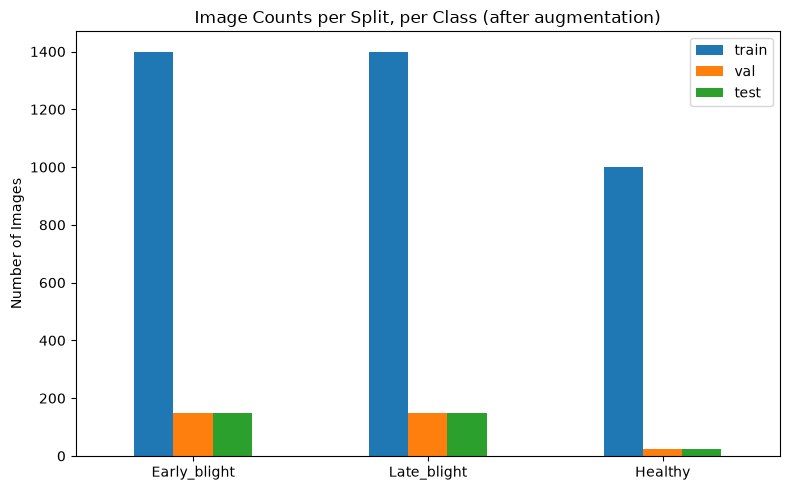

In [10]:
import pandas as pd

summary_df = pd.DataFrame(final_counts).fillna(0).astype(int)
print(summary_df)

fig, ax = plt.subplots(figsize=(8, 5))
summary_df.plot(kind='bar', ax=ax)
ax.set_title('Image Counts per Split, per Class (after augmentation)')
ax.set_ylabel('Number of Images')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Sanity Check — Visualize a Few Augmented Samples

Quick visual check that augmentation looks reasonable (no corrupted images, no obvious artifacts).


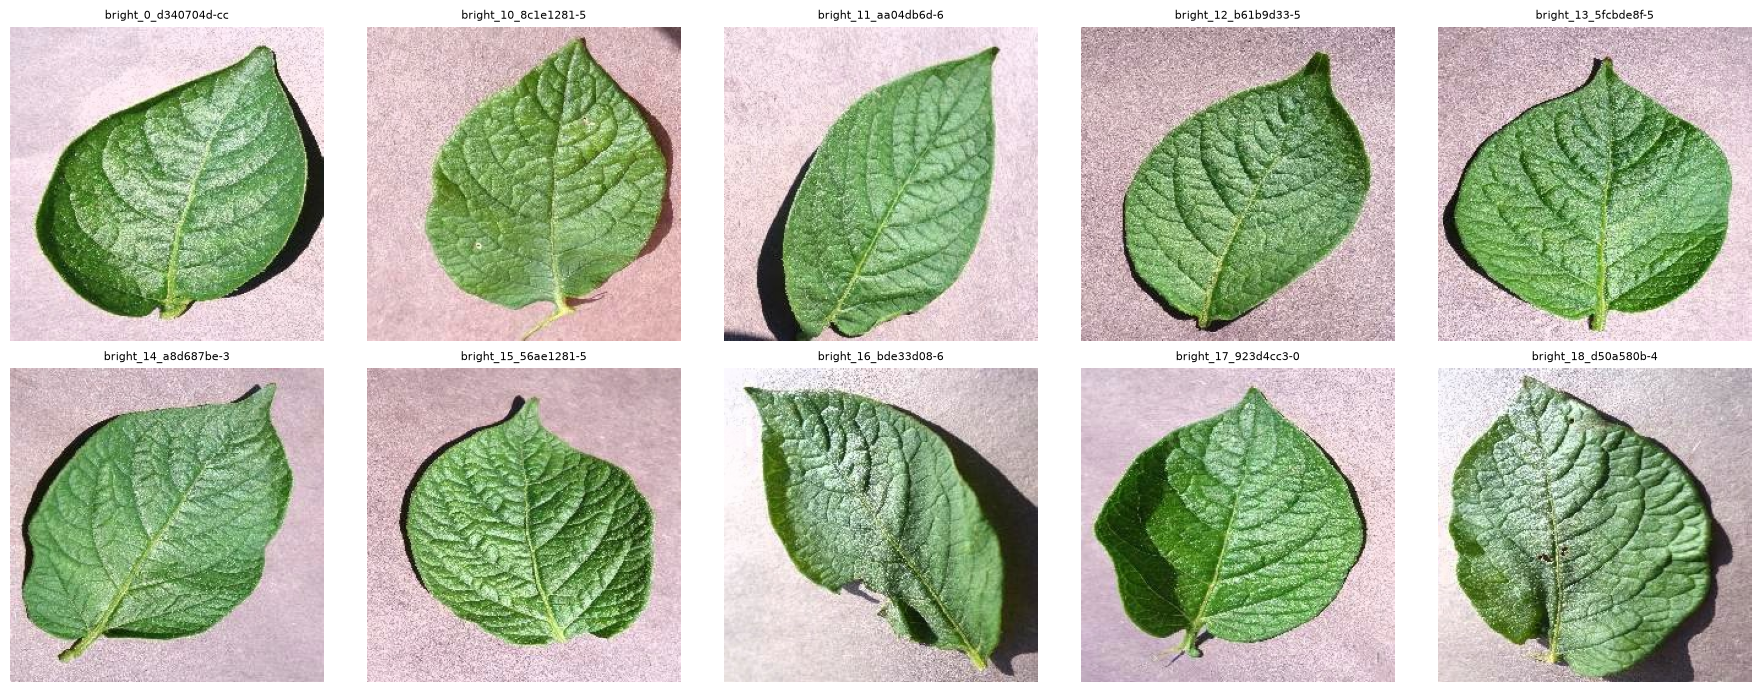

In [11]:
sample_class = 'Healthy'
sample_dir = os.path.join(processed_dir, 'train', sample_class)
sample_files = os.listdir(sample_dir)[:10]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, fname in enumerate(sample_files):
    img = cv2.imread(os.path.join(sample_dir, fname))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i // 5, i % 5].imshow(img_rgb)
    axes[i // 5, i % 5].set_title(fname[:20], fontsize=8)
    axes[i // 5, i % 5].axis('off')
plt.tight_layout()
plt.show()
